In [1]:
import os
import json
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from scipy.optimize import minimize_scalar
from datetime import datetime

from geometry_param import get_params, get_quad_params



In [2]:
# ============================================================
# LOAD TRAJECTORY
# ============================================================

traj_filename = "results/sim_data_04052026_0546.npz"

traj = np.load(traj_filename, allow_pickle=True)

t_hist  = traj['t']
n_hist  = traj['n']
nd_hist = traj['nd']

tau_true_hist = traj['tau'] if 'tau' in traj.files else None
F_true_hist   = traj['F']   if 'F' in traj.files else None

print("Trajectory loaded.")
print("t shape :", t_hist.shape)
print("n shape :", n_hist.shape)
print("nd shape:", nd_hist.shape)


Trajectory loaded.
t shape : (1000,)
n shape : (1000, 3)
nd shape: (1000, 3)


In [3]:
# ============================================================
# DESERIALIZATION
# ============================================================

SYMPY_LOCALS = {
    name: getattr(sp, name)
    for name in dir(sp)
}

SYMPY_LOCALS.update({
    "Derivative": sp.Derivative
})

def deserialize_fast(obj):

    if isinstance(obj, dict) and "__sympy__" in obj:
        return eval(obj["expr"], SYMPY_LOCALS)

    elif isinstance(obj, dict):
        return {
            k: deserialize_fast(v)
            for k, v in obj.items()
        }

    elif isinstance(obj, list):
        return [
            deserialize_fast(v)
            for v in obj
        ]

    else:
        return obj


In [4]:
# ============================================================
# LOAD SYMBOLIC MODEL
# ============================================================

symbolic_filename = "cache/3DOF_symbolic_data_08052026_1944.json"

with open(symbolic_filename, "r") as f:
    raw = json.load(f)

data = deserialize_fast(raw)

print("Symbolic model loaded.")

Symbolic model loaded.


In [5]:
# ============================================================
# EXTRACT SYMBOLICS
# ============================================================

M_sym = data['M']
h_sym = data['h']
Q_sym = data['Q']

C_AN_sym   = data['C_AN']
Jv_b_N_sym = data['Jv_b_N']
Jw_b_B_sym = data['Jw_b_B']


In [6]:
# ============================================================
# STATES
# ============================================================

n   = data['n']
nd  = data['nd']
ndd = data['ndd']

params_sym = data['params']


In [7]:
# ============================================================
# BUILD ARGUMENT LIST
# ============================================================

state_syms = list(n) + list(nd)

param_syms = list(params_sym.values())

tau_syms = sp.symbols('tau1 tau2 tau3')
F_syms   = sp.symbols('Fx Fy Fz')

dyn_args = (
    *state_syms,
    *param_syms,
    *tau_syms,
    *F_syms
)

In [8]:
# ============================================================
# CHECK SYMBOL CONSISTENCY
# ============================================================

free_syms = (
    M_sym.free_symbols
    | h_sym.free_symbols
    | Q_sym.free_symbols
    | C_AN_sym.free_symbols
    | Jv_b_N_sym.free_symbols
    | Jw_b_B_sym.free_symbols
)

missing = free_syms - set(dyn_args)

print("\nMissing symbols:")
print(missing)


Missing symbols:
set()


In [9]:
# ============================================================
# NUMERIC PARAMETERS
# ============================================================

params_num = get_params()

param_vals = list(params_num.values())


In [10]:
# ============================================================
# LAMBDIFY
# ============================================================

print("\nLambdifying dynamics...")

M_func = sp.lambdify(
    dyn_args,
    M_sym,
    modules='numpy'
)

h_func = sp.lambdify(
    dyn_args,
    h_sym,
    modules='numpy'
)

Q_func = sp.lambdify(
    dyn_args,
    Q_sym,
    modules='numpy'
)

print("Lambdifying Jacobians...")

Jv_func = sp.lambdify(
    dyn_args,
    Jv_b_N_sym,
    modules='numpy'
)

Jw_func = sp.lambdify(
    dyn_args,
    Jw_b_B_sym,
    modules='numpy'
)

CAN_func = sp.lambdify(
    dyn_args,
    C_AN_sym,
    modules='numpy'
)

print("Done.\n")



Lambdifying dynamics...
Lambdifying Jacobians...
Done.



In [11]:
# ============================================================
# ACCELERATION ESTIMATION
# ============================================================

print("Estimating accelerations...")

dt_mean = np.mean(np.diff(t_hist))

window_length = 21
polyorder      = 3

ndd_hist = savgol_filter(
    nd_hist,
    window_length=window_length,
    polyorder=polyorder,
    deriv=1,
    delta=dt_mean,
    axis=0
)

print("ndd shape:", ndd_hist.shape)


Estimating accelerations...
ndd shape: (1000, 3)


## Quadcopter Wrench Constraint For Estimation

The dynamics provide only three generalized equations,

\begin{equation*}
Q = M(q)\ddot q + h(q,\dot q),
\end{equation*}

but a general body wrench has six unknowns, $({}^B F\in\mathbb{R}^3)$ and $({}^B\tau\in\mathbb{R}^3)$. To make estimation identifiable, we use the same quadcopter wrench family used in simulation.

Rotor thrust and drag are

\begin{equation*}
f_i = k_f\Omega_i^2, \qquad \tau_{d,i}=k_m\Omega_i^2.
\end{equation*}

The net body-frame wrench at body COM `B` is

\begin{equation*}
{}^B F(u) = \begin{bmatrix}0 \\ 0 \\ \sum_i f_i(u)\end{bmatrix}
\end{equation*}

\begin{equation*}
{}^B \tau(u) = \begin{bmatrix}
\ell(f_2(u)-f_4(u)) \\
\ell(f_3(u)-f_1(u)) \\
k_m(\Omega_1^2(u)-\Omega_2^2(u)+\Omega_3^2(u)-\Omega_4^2(u))
\end{bmatrix}.
\end{equation*}

The scalar $(u)$ is a hidden maneuver coordinate. We do **not** use measured RPMs. At each timestep we estimate $(u)$ by matching the generalized force implied by the measured trajectory:

\begin{equation*}
\hat u = \arg\min_u \left\|Q_{traj} - \left(J_{v,B}^T {}^B F(u) + J_\omega^T {}^B\tau(u)\right)\right\|_2^2.
\end{equation*}

This replaces the previous arbitrary relation $(\tau=b+AF)$, which did not match the quadcopter simulator.


In [12]:
# ============================================================
# QUADCOPTER WRENCH FAMILY USED BY THE ESTIMATOR
# ============================================================
# If the trajectory file contains quad_config, use it. Otherwise fall back to
# the current static geometry_param.py values and the local maneuver defaults.
if 'quad_config' in traj.files:
    quad_config = traj['quad_config'].item()
else:
    quad_static = get_quad_params()
    quad_config = {
        'model_name': quad_static['model_name'],
        'spec_source_url': quad_static['spec_source_url'],
        'frame_span_m': quad_static['frame_span_m'],
        'MANEUVER_MODE': 'roll',
        'quad_l': quad_static['quad_l'],
        'body_mass_total_kg': params_num['mb'],
        'body_inertia_diag': np.array([params_num['Ibx'], params_num['Iby'], params_num['Ibz']], dtype=float),
        'kf': 2.0e-8,
        'km': 2.0e-10,
        'hover_rpm': 4200.0,
        'roll_amplitude_rpm': 700.0,
        'pitch_amplitude_rpm': 700.0,
        'yaw_amplitude_rpm': 700.0,
    }
    print(
        'WARN: trajectory file does not contain quad_config. '
        'Using static geometry_param.py values and local maneuver defaults.'
    )

MANEUVER_MODE = quad_config.get('MANEUVER_MODE', 'roll')
quad_l = float(quad_config.get('quad_l', get_quad_params()['quad_l']))
kf = float(quad_config.get('kf', 2.0e-8))
km = float(quad_config.get('km', 2.0e-10))
hover_rpm = float(quad_config.get('hover_rpm', 4200.0))
hover_omega = hover_rpm * (2.0 * np.pi / 60.0)

if MANEUVER_MODE == 'roll':
    maneuver_amp_rpm = float(quad_config.get('roll_amplitude_rpm', 700.0))
elif MANEUVER_MODE == 'pitch':
    maneuver_amp_rpm = float(quad_config.get('pitch_amplitude_rpm', 700.0))
elif MANEUVER_MODE == 'yaw':
    maneuver_amp_rpm = float(quad_config.get('yaw_amplitude_rpm', 700.0))
else:
    maneuver_amp_rpm = 0.0

maneuver_amp_omega = maneuver_amp_rpm * (2.0 * np.pi / 60.0)

# Search bounds for the hidden maneuver coordinate u [rad/s].
u_bound = max(2.0 * abs(maneuver_amp_omega), 0.25 * hover_omega, 1e-6)
u_bounds = (-u_bound, u_bound)


def rotor_speeds_from_mode(u):
    """Return rotor angular speeds [w1,w2,w3,w4] for the selected maneuver."""
    w = np.full(4, hover_omega, dtype=float)

    if MANEUVER_MODE == 'hover':
        w += u
    elif MANEUVER_MODE == 'roll':
        w[1] += u
        w[3] -= u
    elif MANEUVER_MODE == 'pitch':
        w[0] -= u
        w[2] += u
    elif MANEUVER_MODE == 'yaw':
        w[0] += u
        w[2] += u
        w[1] -= u
        w[3] -= u
    else:
        raise ValueError(f'Unknown MANEUVER_MODE: {MANEUVER_MODE}')

    return w


def quad_wrench_from_mode_coordinate(u):
    """Map hidden maneuver coordinate u to net body-frame force and torque."""
    omega = rotor_speeds_from_mode(u)
    if np.any(omega < 0.0):
        return None, None

    w1, w2, w3, w4 = omega
    f1, f2, f3, f4 = kf * omega**2

    F_B = np.array([0.0, 0.0, f1 + f2 + f3 + f4])
    tau_B = np.array([
        quad_l * (f2 - f4),
        quad_l * (f3 - f1),
        km * (w1**2 - w2**2 + w3**2 - w4**2),
    ])
    return F_B, tau_B


print('Estimator quad maneuver mode:', MANEUVER_MODE)
print('Search bounds for hidden u [rad/s]:', u_bounds)
print('Nominal hover wrench (F_B, tau_B):')
print(quad_wrench_from_mode_coordinate(0.0))



WARN: trajectory file does not contain quad_config. Using default estimator quad settings; rerun 3dof_simulate_2.ipynb with SAVE_TRAJ_FLAG=True for a matched test.
Estimator quad maneuver mode: roll
Search bounds for hidden u [rad/s]: (-109.95574287564276, 109.95574287564276)
Nominal hover wrench (F_B, tau_B):
(array([  0.        ,   0.        , 170.23093671]), array([0., 0., 0.]))


In [13]:
# ============================================================
# STORAGE
# ============================================================
N = len(t_hist)

u_est_hist = np.zeros(N)
F_est_hist = np.zeros((N, 3))
tau_est_hist = np.zeros((N, 3))

Q_hist = np.zeros((N, 3))
Q_model_hist = np.zeros((N, 3))
fit_residual_hist = np.zeros((N, 3))
fit_cost_hist = np.zeros(N)
cond_hist = np.zeros(N)



In [14]:
# ============================================================
# ESTIMATION LOOP
# ============================================================
print("\nEstimating hidden maneuver coordinate and net wrench...\n")

for k in range(N):
    q = n_hist[k]
    qd = nd_hist[k]
    qdd = ndd_hist[k]

    n1, n2, n3 = q
    n1d, n2d, n3d = qd

    # Dummy inputs are used because M, h, C_AN, Jv, and Jw do not depend on the input values.
    tau_dummy = [0.0, 0.0, 0.0]
    F_dummy = [0.0, 0.0, 0.0]

    args = (
        n1, n2, n3,
        n1d, n2d, n3d,
        *param_vals,
        *tau_dummy,
        *F_dummy,
    )

    M_k = np.array(M_func(*args), dtype=float)
    h_k = np.array(h_func(*args), dtype=float).reshape(3)

    # Generalized force implied by the trajectory.
    Q_k = M_k @ qdd + h_k

    Jv_N_k = np.array(Jv_func(*args), dtype=float)
    Jw_k = np.array(Jw_func(*args), dtype=float)
    C_AN_k = np.array(CAN_func(*args), dtype=float)

    # Convert translational Jacobian from N components to B/A components.
    # B is assumed aligned with A, matching the simulator.
    Jv_B_k = C_AN_k @ Jv_N_k

    def Q_from_u(u):
        F_B, tau_B = quad_wrench_from_mode_coordinate(u)
        if F_B is None:
            return None
        return Jv_B_k.T @ F_B + Jw_k.T @ tau_B

    def objective(u):
        Q_model = Q_from_u(u)
        if Q_model is None:
            return 1e30
        err = Q_model - Q_k
        return float(err @ err)

    opt = minimize_scalar(objective, bounds=u_bounds, method='bounded')
    u_est = float(opt.x)

    F_est, tau_est = quad_wrench_from_mode_coordinate(u_est)
    Q_model = Q_from_u(u_est)
    fit_residual = Q_model - Q_k

    # Local sensitivity/conditioning for the scalar inverse problem.
    du = max(1e-6, 1e-5 * max(1.0, abs(u_est)))
    Q_plus = Q_from_u(u_est + du)
    Q_minus = Q_from_u(u_est - du)
    if Q_plus is not None and Q_minus is not None:
        dQ_du = (Q_plus - Q_minus) / (2.0 * du)
        cond_hist[k] = 1.0 / max(np.linalg.norm(dQ_du), 1e-12)
    else:
        cond_hist[k] = np.inf

    u_est_hist[k] = u_est
    F_est_hist[k] = F_est
    tau_est_hist[k] = tau_est
    Q_hist[k] = Q_k
    Q_model_hist[k] = Q_model
    fit_residual_hist[k] = fit_residual
    fit_cost_hist[k] = float(opt.fun)

print("Estimation complete.")
print("Max |Q fit residual|:", np.max(np.abs(fit_residual_hist)))
print("RMS |Q fit residual|:", np.sqrt(np.mean(fit_residual_hist**2)))




Estimating hidden maneuver coordinate and net wrench...

Estimation complete.
Max |Q fit residual|: 27.240585347730118
RMS |Q fit residual|: 15.725262871319122


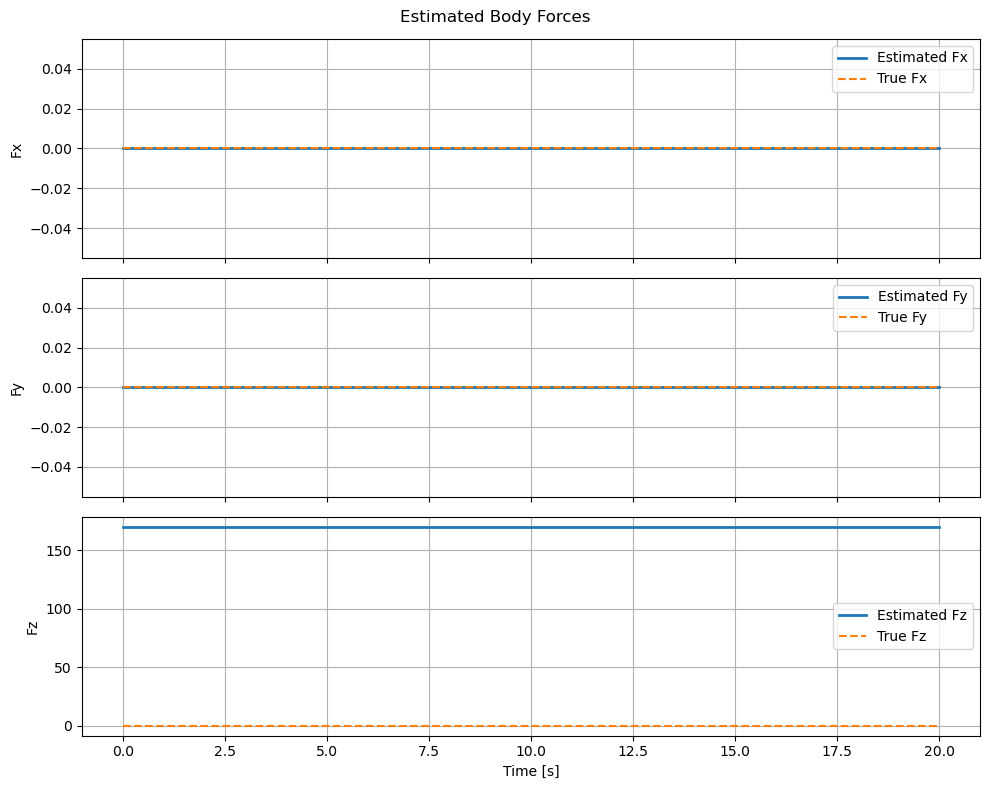

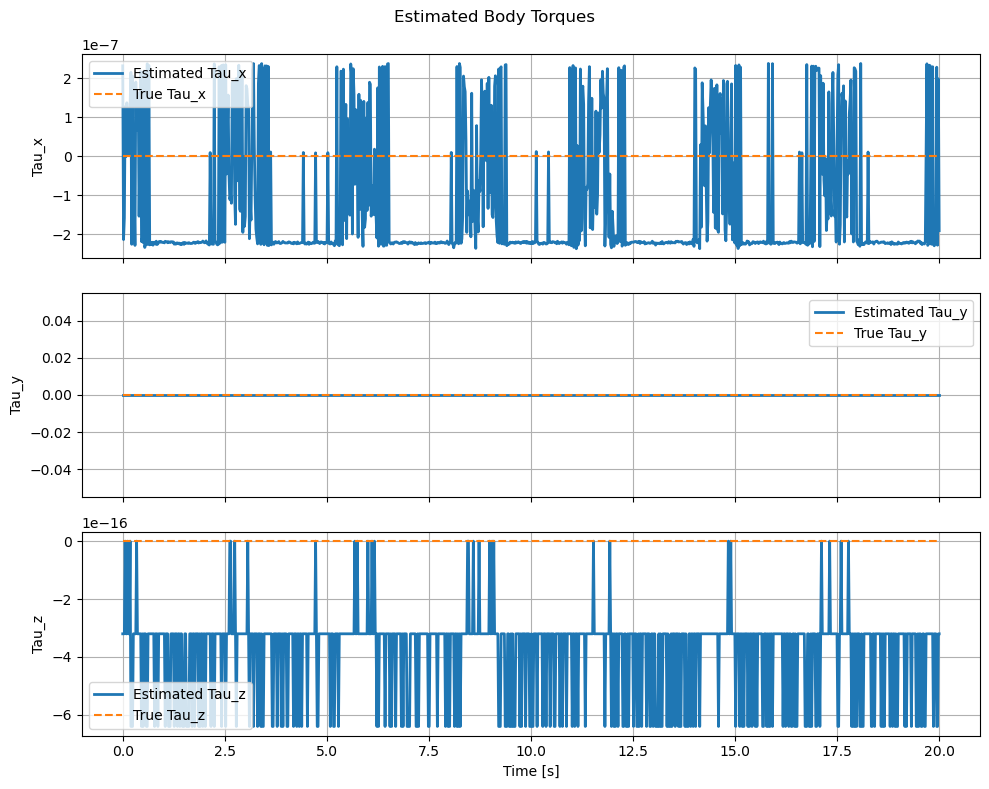

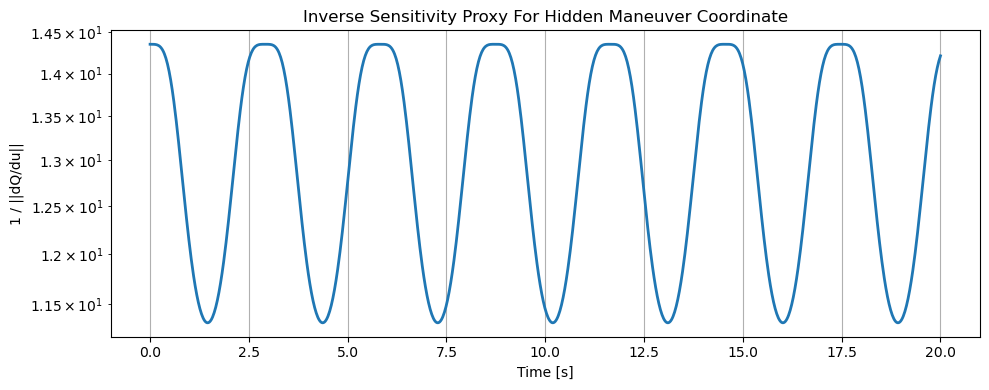

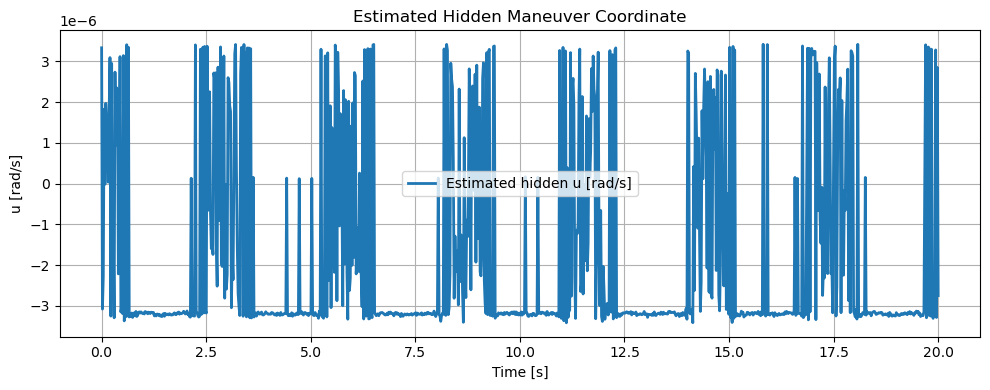

In [15]:
# ============================================================
# FORCE PLOTS
# ============================================================

figF, axF = plt.subplots(
    3,
    1,
    figsize=(10,8),
    sharex=True
)

force_labels = ['Fx', 'Fy', 'Fz']

for i in range(3):

    axF[i].plot(
        t_hist,
        F_est_hist[:,i],
        linewidth=2,
        label=f'Estimated {force_labels[i]}'
    )

    if F_true_hist is not None:

        axF[i].plot(
            t_hist,
            F_true_hist[:,i],
            '--',
            linewidth=1.5,
            label=f'True {force_labels[i]}'
        )

    axF[i].set_ylabel(force_labels[i])

    axF[i].grid(True)

    axF[i].legend()

axF[-1].set_xlabel('Time [s]')

figF.suptitle('Estimated Body Forces')

plt.tight_layout()

# ============================================================
# TORQUE PLOTS
# ============================================================

figTau, axTau = plt.subplots(
    3,
    1,
    figsize=(10,8),
    sharex=True
)

tau_labels = ['Tau_x', 'Tau_y', 'Tau_z']

for i in range(3):

    axTau[i].plot(
        t_hist,
        tau_est_hist[:,i],
        linewidth=2,
        label=f'Estimated {tau_labels[i]}'
    )

    if tau_true_hist is not None:

        axTau[i].plot(
            t_hist,
            tau_true_hist[:,i],
            '--',
            linewidth=1.5,
            label=f'True {tau_labels[i]}'
        )

    axTau[i].set_ylabel(tau_labels[i])

    axTau[i].grid(True)

    axTau[i].legend()

axTau[-1].set_xlabel('Time [s]')

figTau.suptitle('Estimated Body Torques')

plt.tight_layout()

# ============================================================
# CONDITION NUMBER PLOT
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(
    t_hist,
    cond_hist,
    linewidth=2
)

plt.yscale('log')

plt.grid(True)

plt.xlabel('Time [s]')

plt.ylabel('1 / ||dQ/du||')

plt.title('Inverse Sensitivity Proxy For Hidden Maneuver Coordinate')

plt.tight_layout()
plt.show()
# ============================================================
# HIDDEN MANEUVER COORDINATE PLOT
# ============================================================
plt.figure(figsize=(10,4))
plt.plot(t_hist, u_est_hist, linewidth=2, label='Estimated hidden u [rad/s]')
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('u [rad/s]')
plt.title('Estimated Hidden Maneuver Coordinate')
plt.legend()
plt.tight_layout()
plt.show()



In [16]:
# ============================================================
# OPTIONAL SAVE
# ============================================================

SAVE_ESTIMATION = False

if SAVE_ESTIMATION:

    save_dir = "results"

    os.makedirs(save_dir, exist_ok=True)

    timestamp_now = datetime.now().strftime("%d%m%Y_%H%M")

    save_filename = os.path.join(
        save_dir,
        f"estimated_wrench_{timestamp_now}.npz"
    )

    np.savez_compressed(
        save_filename,

        t=t_hist,

        u_est=u_est_hist,
        F_est=F_est_hist,
        tau_est=tau_est_hist,

        Q=Q_hist,
        Q_model=Q_model_hist,
        Q_fit_residual=fit_residual_hist,
        fit_cost=fit_cost_hist,
        inverse_sensitivity=cond_hist,

        maneuver_mode=MANEUVER_MODE,
        quad_l=quad_l,
        kf=kf,
        km=km,
        hover_omega=hover_omega
    )

    print(f"\nSaved estimated wrench data to:\n{save_filename}")
